In [1]:
import numpy as np
import requests
import matplotlib.pyplot as plt

# Nótese el random_split
from torch.utils.data import Dataset, DataLoader, random_split
import torch
import torch.nn as nn
from torch.nn import functional as F

## 5. Preentrenamiento: Inclusión del Conjunto de Prueba (`test_size`)

En el ejercicio anterior entrenamos el modelo utilizando la totalidad del conjunto de datos, sin reservar una partición de prueba independiente para su evaluación.

Omitir este conjunto de prueba introduce un riesgo crítico: los resultados observados podrían deberse a un exceso de sobreajuste (*overfitting*). Esto implica que el modelo podría estar simplemente memorizando secuencias específicas del texto en lugar de aprender regularidades y patrones estadísticos transferibles a datos no vistos.

Añadir un conjunto de prueba (*test set*) no es difícil, ni a nivel conceptual ni matemático; únicamente requiere unas pocas líneas de código adicionales en el flujo de trabajo.

### ¿Por qué lo necesitamos?

Debemos tener en cuenta que la optimización de los modelos suele funcionar bien sobre los datos con los que fueron entrenados. Por supuesto, no siempre es automático: la arquitectura, los hiperparámetros, la función de pérdida, el procesamiento y la calidad del conjunto de datos deben estar bien diseñados. Sin embargo, lograr un buen rendimiento sobre los datos de entrenamiento es relativamente fácil porque, cuando el modelo los procesa repetidamente a lo largo de varias épocas, comienza a memorizarlos (por ejemplo, memorizando secuencias exactas de tokens en un texto).

Para diagnosticar esto, la idea es evaluar el modelo en un conjunto de datos separado: una partición que mantenga una distribución similar a la del conjunto de entrenamiento, pero que el modelo jamás haya visto. Durante esta evaluación, el modelo no debe aprender, lo que significa que es indispensable **desactivar el cálculo del gradiente** en el bucle de validación/prueba.

Cabe destacar que el sobreajuste (*overfitting*) tiende a ser un problema mucho menor en los grandes modelos de lenguaje (LLMs). Al entrenarse con volúmenes masivos de datos (billones de tokens), el conjunto de entrenamiento posee una enorme variabilidad estadística y, en la mayoría de los casos de preentrenamiento moderno, el modelo apenas ve cada token una o dos veces (*single-epoch training*), favoreciendo de forma natural la generalización.

In [2]:
# en DL se usan muchos epochs en LLMS probablemente con 4 o 5 epocas es una cantidad gigantesca de texto (no hay mucha repeticion y no tiene mucha oportunidad de sobreajustarse)

# **Split** 90% 10%

### División de Datos: Conjunto de Entrenamiento vs. Prueba

Para estructurar la validación, dividimos los tokens del corpus en dos particiones independientes:

* **Conjunto de entrenamiento (`train_set` - 90%):**  
  Se utiliza exclusivamente para ajustar los pesos del modelo. Aquí intervienen de forma activa la función de pérdida, la retropropagación (*backpropagation*), el cálculo de gradientes y el optimizador.

* **Conjunto de prueba (`test_set` - 10% restante):**  
  Se aparta para evaluar la capacidad de generalización del modelo al final de cada época (*epoch*). Durante esta fase:
  * **No hay gradientes:** Desconectamos el grafo de cómputo (`torch.no_grad()`).
  * **No hay retropropagación:** No se ejecuta `loss.backward()`.
  * **No hay optimizador:** El optimizador no actualiza los pesos (`optimizer.step()` se omite).

---

### Evaluación sin Optimización

En el conjunto de prueba sí calculamos la función de pérdida (Cross-Entropy Loss), ya que nuestro objetivo es medir cuantitativamente el error sobre datos no vistos. Sin embargo, esta pérdida no genera retroalimentación para la tasa de aprendizaje (*learning rate*) ni modifica los parámetros: su único propósito es servir como métrica diagnóstica.

---

### Muestreo y Extracción de Secuencias

En la práctica, al trabajar con grandes volúmenes de texto, es habitual no procesar los datos de forma lineal estricta, sino **extraer muestras aleatorias de longitud fija (`sequence_length`) y organizarlas en lotes (`batches`)** a lo largo del corpus.

Que esta estrategia de muestreo aleatorio sea estrictamente necesaria frente a una partición secuencial estándar depende de la naturaleza del conjunto de datos y de la estructura temporal o narrativa del texto que se esté modelando.

In [3]:
# Tokenizador de GPT-2
from transformers import GPT2Tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Hyperparametros

In [5]:
# Hiperparámetros de datos
seq_len = 8 # alias longitud de contexto
stride = 2

# Hiperparámetros del modelo
embed_dim = 128

# Hiperparámetros de entrenamiento
batch_size = 64

## Crear el Trai,Test set

In [6]:
# Descargar y tokenizar el texto
text = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text
tmTokens = torch.tensor(tokenizer.encode(text))

# Contar el número de tokens

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (45295 > 1024). Running this sequence through the model will result in indexing errors


In [7]:
# Crear una clase para el conjunto de datos (nota: el agrupamiento en lotes lo realiza el DataLoader, no el dataset)
class TokenDataset(Dataset):
  def __init__(self, tokens, seq_len=8, stride=4):

    # Inicializar
    self.inputs  = []
    self.targets = []

    # Secuencias superpuestas de longitud seq_len
    for i in range(0, len(tokens) - seq_len, stride):

      # Obtener tokens y agregarlos a las listas
      self.inputs.append( tokens[i     : i + seq_len])
      self.targets.append(tokens[i + 1 : i + seq_len + 1])

  def __len__(self):
    return len(self.inputs)

  def __getitem__(self, idx):
    return self.inputs[idx], self.targets[idx]

In [8]:
# Crear una instancia
token_dataset = TokenDataset(tmTokens, seq_len, stride)

# Dividir en entrenamiento y prueba
train_ratio = 0.9
train_size = int(train_ratio * len(token_dataset))
test_size = len(token_dataset) - train_size

# Crear subconjuntos de entrenamiento y prueba
train_dataset, test_dataset = random_split(
    token_dataset, [train_size, test_size]
)

# Crear los DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) # barajear tokens aleatorios ( es bueno para evitar cualquier reisgo de sesgo sistematico en el modelo)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)  # no barajear los datos

print(f'El conjunto de entrenamiento tiene {train_size} secuencias.')
print(f'El conjunto de prueba tiene        {test_size} secuencias.')

El conjunto de entrenamiento tiene 20379 secuencias.
El conjunto de prueba tiene        2265 secuencias.


### Explicación breve

* **División 90/10:** El total de secuencias extraídas del libro ($22\,644$) se dividió en un **90% para entrenamiento** ($20\,379$) y un **10% para evaluación** ($2\,265$).
* **Propósito del conjunto de entrenamiento:** Son los ejemplos con los que el modelo ajustará sus pesos mediante retropropagación para aprender las probabilidades del lenguaje.
* **Propósito del conjunto de prueba:** Sirve como datos no vistos para evaluar la capacidad de generalización del modelo y detectar posible sobreajuste (*overfitting*), comprobando si realmente aprendió patrones o solo memorizó el texto de entrenamiento.

## Crear el Modelo

In [9]:
class Model(nn.Module):
  def __init__(self):
    super().__init__()

    # Matriz de embeddings: de tamaño de vocabulario a dimensión latente
    self.embedding = nn.Embedding(tokenizer.vocab_size, embed_dim)

    # Activación no lineal
    self.gelu = nn.GELU()

    # Capa lineal de salida: proyección inversa al vocabulario completo
    self.finalLinear = nn.Linear(embed_dim, tokenizer.vocab_size, bias=False)

  def forward(self, tokx):
    # Propagación hacia adelante
    # tokx: [batch, sequence_length] -> x: [batch, sequence_length, embed_dim]
    x = self.embedding(tokx)
    x = self.gelu(x)
    x = self.finalLinear(x) # [batch, sequence_length, vocab_size]

    # Retornar log-softmax a lo largo del eje del vocabulario (dim=-1)
    return F.log_softmax(x, dim=-1)

  def generate(self, tokx, n_new_tokens=30):
    for _ in range(n_new_tokens):
      # Pasar por el modelo
      x = self(tokx)
      # Conservar únicamente la predicción del último token de la secuencia: [batch, vocab_size]
      x = x[:, -1, :]
      # Deshacer el logaritmo para recuperar probabilidades reales
      probs = torch.exp(x)
      # Muestreo probabilístico para elegir el siguiente token
      tokx_next = torch.multinomial(probs, num_samples=1)
      # Concatenar el nuevo token al contexto
      tokx = torch.cat((tokx, tokx_next), dim=1)
    return tokx

In [10]:
# Crear una instancia y probar
model = Model()

# Extraer un lote del dataloader
X, y = next(iter(train_dataloader))

# Pasar los datos a través del modelo
out = model(X)

print(X.shape)
print(y.shape)
print(out.shape)

torch.Size([64, 8])
torch.Size([64, 8])
torch.Size([64, 8, 50257])


In [11]:
# Confirmar la distribución de probabilidad

# Suma de probabilidades para todas las posiciones del primer elemento del lote (debe dar seq_len = 8)
print(torch.sum(torch.exp(out[0])))

# Verificación directa: cada posición individual sobre el vocabulario suma 1.0
print(torch.sum(torch.exp(out[0, 0])))

# Suma total en todo el tensor (debe dar batch_size * seq_len)
print(torch.sum(torch.exp(out)))

# Valores mínimo y máximo de probabilidad observados
print(torch.min(torch.exp(out)))
print(torch.max(torch.exp(out)))

tensor(8.0000, grad_fn=<SumBackward0>)
tensor(1.0000, grad_fn=<SumBackward0>)
tensor(512.0001, grad_fn=<SumBackward0>)
tensor(1.9840e-06, grad_fn=<MinBackward1>)
tensor(0.0002, grad_fn=<MaxBackward1>)


### Verificación de la Distribución de Probabilidades

Para confirmar que la salida del modelo representa una distribución de probabilidad válida tras revertir el logaritmo (`torch.exp(out)`), validamos dos condiciones matemáticas esenciales:

1. **No-negatividad ($P \ge 0$):**  
   * **Valor mínimo:** $\approx 1.93 \times 10^{-6}$. Aunque el exponente es negativo, el valor es **estrictamente positivo**, lo que confirma que ninguna probabilidad cae por debajo de cero.
   * **Valor máximo:** $\approx 0.0001$. Refleja que, antes de entrenar, el modelo asigna una probabilidad baja y relativamente uniforme a lo largo de las 50,257 clases del vocabulario.

2. **Normalización ($\sum P = 1$):**  
   * La suma total de todo el tensor arroja exactamente **512**.
   * Esto valida la normalización del modelo: dado que procesamos un lote de **64 secuencias** y cada una tiene **8 tokens** de longitud, la suma acumulada de las distribuciones unitarias a lo largo de todo el lote es $64 \times 8 \times 1.0 = 512$.

### ¿La salida del modelo es una distribución de probabilidad?

**Respuesta: No de forma directa.**

1. **La salida directa (`out`) son log-probabilidades:**  
   Como la última capa utiliza `F.log_softmax()`, los valores que devuelve el modelo son logaritmos naturales de las probabilidades ($\ln(P)$). Estos números son negativos y no suman 1.

2. **La transformación con la exponencial (`torch.exp(out)`):**  
   Para obtener una distribución de probabilidad real, invertimos el logaritmo aplicando la función exponencial. Al calcular $e^{\text{out}}$:
   * Todos los valores se vuelven **no negativos** ($P \ge 0$).
   * La suma de las probabilidades para cada token pasa a ser exactamente **1.0**.

---

### Propiedad matemática: ¿La suma de las exponenciales es igual a la exponencial de la suma?

**Respuesta: Falso.**

La regla algebraica de los exponentes establece una multiplicación, no una suma:

$$e^{a + b} = e^a \cdot e^b \quad (\text{y no } e^a + e^b)$$

#### Ejemplo numérico con $a = 1$ y $b = 2$:
* **Suma de exponenciales:**  
  $$e^1 + e^2 \approx 2.718 + 7.389 = \mathbf{10.107}$$

* **Exponencial de la suma:**  
  $$e^{1 + 2} = e^3 \approx \mathbf{20.085}$$

Por lo tanto:
$$\sum e^x \neq e^{\sum x}$$

### Conclusión

1. **La salida cruda del modelo no es una distribución de probabilidad:**  
   Al aplicar `F.log_softmax(x, dim=-1)`, el modelo devuelve **log-probabilidades**[cite: 1]. Estos valores son negativos y no cumplen la condición de sumar $1.0$.

2. **Se transforma aplicando la exponencial:**  
   Para obtener una distribución de probabilidad válida, es estrictamente necesario aplicar la función exponencial inversa:
   $$\text{probabilidades} = \exp(\text{out})$$
   Solo tras esta operación los valores quedan en el rango $[0, 1]$ y las probabilidades de cada token individual suman exactamente $1.0$.

3. **No se puede sumar antes de exponenciar:**  
   Debido a que $\sum e^x \neq e^{\sum x}$, no es equivalente sumar las log-probabilidades y luego aplicar la exponencial. Se debe exponenciar primero cada valor individualmente y luego sumar para verificar o normalizar la distribución.

# Entrenamiento del modelo

In [12]:
# Mover el modelo a la GPU
model = model.to(device)

In [13]:
# Crear la función de pérdida y el optimizador
loss_function = nn.NLLLoss().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

In [14]:
num_epochs = 10

# Inicializar listas de pérdidas
train_loss = []
test_loss = []

for epoch in range(num_epochs):

  # Inicializar pérdida por época
  epoch_loss = 0

  # Iterar sobre los lotes del dataloader de entrenamiento
  for X, y in train_dataloader:

    # Mover datos a la GPU
    X, y = X.to(device), y.to(device)

    # Reiniciar gradientes acumulados
    model.zero_grad()

    # Propagación hacia adelante
    log_probs = model(X)

    # Calcular la pérdida aplanando las dimensiones: [batch * seq_len, vocab_size] y [batch * seq_len]
    log_probs_flat = log_probs.view(-1, log_probs.shape[-1])
    y_flat = y.view(-1)
    loss = loss_function(log_probs_flat, y_flat)

    # Retropropagación y paso del optimizador
    loss.backward()
    optimizer.step()

    # Acumular la pérdida por época
    epoch_loss += loss.item()
  # Fin del bucle de lotes de entrenamiento

  # Evaluar el modelo con el conjunto de prueba
  with torch.no_grad():
    testloss = 0  # Reiniciar la pérdida de prueba
    for X, y in test_dataloader:
      X, y = X.to(device), y.to(device)             # Mover datos a la GPU
      out = model(X)                                # Propagación hacia adelante
      out_flat = out.reshape(-1, out.shape[-1])     # Aplanar salida
      thisloss = loss_function(out_flat, y.view(-1)) # Calcular pérdida
      testloss += thisloss.item()                   # Acumular a la pérdida de prueba

  # Promediar la pérdida dividiendo por el número de lotes
  train_loss.append(epoch_loss / len(train_dataloader))
  test_loss.append(testloss / len(test_dataloader))

  # Mostrar progreso por época
  print(f'Época {epoch+1:2}, pérdida entrenamiento: {epoch_loss / len(train_dataloader):.4f}, pérdida prueba: {testloss / len(test_dataloader):.4f}')

Época  1, pérdida entrenamiento: 6.6831, pérdida prueba: 5.3085
Época  2, pérdida entrenamiento: 4.8358, pérdida prueba: 4.6913
Época  3, pérdida entrenamiento: 4.3224, pérdida prueba: 4.3264
Época  4, pérdida entrenamiento: 4.0012, pérdida prueba: 4.0800
Época  5, pérdida entrenamiento: 3.7866, pérdida prueba: 3.9015
Época  6, pérdida entrenamiento: 3.6325, pérdida prueba: 3.7697
Época  7, pérdida entrenamiento: 3.5170, pérdida prueba: 3.6653
Época  8, pérdida entrenamiento: 3.4256, pérdida prueba: 3.5838
Época  9, pérdida entrenamiento: 3.3508, pérdida prueba: 3.5136
Época 10, pérdida entrenamiento: 3.2900, pérdida prueba: 3.4563


In [17]:
# Cuando evaluamos un modelo con el test set desactivamos los calculos de los gradientes del modelo

### ¿Por qué usamos `torch.no_grad()` en la evaluación?

El gestor de contexto `with torch.no_grad():` desactiva por completo el motor de diferenciación automática (*Autograd*) durante la inferencia o evaluación.

---

#### 1. Qué ocurre si no usamos `torch.no_grad()`
Por defecto, cada operación matemática que involucra tensores con `requires_grad=True` (como los pesos y sesgos del modelo) construye un **grafo acíclico dirigido (DAG)** en memoria.
* Este grafo rastrea cada multiplicación, suma y activación para calcular derivadas parciales en caso de llamar a `.backward()`.
* Si no ejecutamos `.backward()`, ese grafo se construye en vano, acumulando tensores intermedios en la memoria RAM/VRAM hasta que el lote concluye.

---

#### 2. Beneficios de desactivarlo

* **Ahorro de memoria (VRAM / RAM):**  
  Al no tener que almacenar los mapas de activación intermedios para la propagación hacia atrás, el consumo de memoria se reduce de forma drástica. Esto permite evaluar con lotes (*batch sizes*) sustancialmente mayores sin provocar errores de *Out of Memory* (OOM).

* **Velocidad de cómputo:**  
  Elimina el sobrecoste computacional (*overhead*) que implica construir y registrar dinámicamente el grafo de operaciones en cada paso del bucle.

---

#### 3. En modelos pequeños vs. LLMs a gran escala

* **En arquitecturas de juguete / modelos reducidos:**  
  Omitirlo puede pasar desapercibido porque el consumo de memoria de unos pocos miles o millones de parámetros es marginal y el hardware no se satura.
* **En LLMs de producción (billones de parámetros):**  
  Es **estrictamente indispensable**. Mantener activos los grafos de cálculo durante la validación colapsaría inmediatamente la memoria de la GPU, además de ralentizar de forma innecesaria el tiempo total de entrenamiento.

---

#### 4. Propósito en la evaluación
Durante la fase de prueba (`test_set`):
1. **Sí llamamos a la función de pérdida (`loss_function`):** Necesitamos un valor escalar para cuantificar el error sobre datos no vistos y monitorizar la generalización.
2. **No llamamos a `loss.backward()` ni a `optimizer.step()`:** El modelo no debe actualizar sus pesos con base en las muestras de prueba.

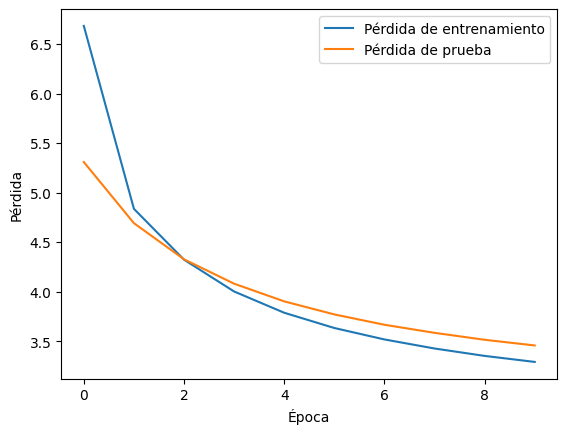

In [21]:
# Graficar las curvas de pérdida
plt.plot(train_loss, label='Pérdida de entrenamiento')
plt.plot(test_loss, label='Pérdida de prueba')

plt.legend()
plt.gca().set(xlabel='Época', ylabel='Pérdida')
plt.show()

### Análisis de las Curvas de Pérdida (Train vs. Test)

1. **Aprendizaje y Convergencia Efectiva:**  
   Tanto la curva de entrenamiento (`Train Loss`) como la de prueba (`Test Loss`) descienden de manera sostenida a lo largo de las 10 épocas (de ~6.7 a ~3.3 en entrenamiento, y de ~5.3 a ~3.5 en prueba). Esto confirma que el modelo está capturando dependencias estadísticas reales del texto.

2. **Comportamiento en las Épocas Iniciales (0 a 2):**  
   En la época 0, la pérdida de prueba es menor que la de entrenamiento. Esto es habitual: `train_loss` acumula el error promedio mientras el modelo aún está desajustado al inicio de la época, mientras que `test_loss` se evalúa al final, cuando los pesos ya se actualizaron a lo largo de todo el conjunto de entrenamiento.

3. **Generalización sin Sobreajuste Severo (*Overfitting*):**  
   A partir de la época 3, la pérdida de entrenamiento se posiciona ligeramente por debajo de la de prueba, lo cual es el comportamiento teórico esperado. La pérdida de prueba **no rebota ni sube** en ningún momento; continúa bajando casi en paralelo, demostrando que el modelo sigue generalizando bien sobre secuencias no vistas y no ha caído en memorización prematura.

In [22]:
# Generar texto nuevo
startToks = torch.tensor(tokenizer.encode('I thought the Eloi would be smarter than')).unsqueeze(0)

Y = model.generate(startToks.to(device), n_new_tokens=80)
print(tokenizer.decode(Y[0].tolist()))

I thought the Eloi would be smarter than the midst my feeling him, I dashed We eyes.“What a rarefied I was caught her with pain I saw another; and at the parent body, I took a match.
will move about in the Psychologist he said the Leal, I determined toiler assured now seemed to them for the
life
“Little Weena, his


most pinn
